In [3]:

import pandas as pd
import glob

# Target: keep all fishing rows + 1 million non-fishing rows.
# Non-fishing is ~28 M rows, so we sample each chunk at frac ≈ 0.04
# (~1.12 M expected) then trim to exactly 1 M after loading.
NON_FISHING_TARGET = 1_000_000
SAMPLE_FRAC        = 0.04          # slight over-sample; trimmed later

csv_files = glob.glob("*.csv")

fishing_chunks     = []
non_fishing_chunks = []

for file in csv_files:
    gear_name = file.replace('.csv', '')
    print(f"Processing {file}...")
    for chunk in pd.read_csv(file, chunksize=100_000):
        # Map is_fishing: -1 -> 0 (non-fishing), 1 -> 1 (fishing)
        chunk['is_fishing'] = chunk['is_fishing'].map({-1: 0, 1: 1})
        chunk = chunk[chunk['is_fishing'].isin([0, 1])]

        # Convert timestamp (Unix seconds) to datetime
        chunk['timestamp'] = pd.to_datetime(chunk['timestamp'], unit='s')

        # Add gear column derived from filename
        chunk['gear'] = gear_name

        # Split and store separately to control memory
        fishing_chunks.append(chunk[chunk['is_fishing'] == 1.0])
        nf = chunk[chunk['is_fishing'] == 0.0]
        if len(nf):
            non_fishing_chunks.append(nf.sample(frac=SAMPLE_FRAC, random_state=42))

# --- Combine fishing rows ---
df_fishing = pd.concat(fishing_chunks, ignore_index=True)

# --- Combine & trim non-fishing rows to exactly 1 M ---
df_nf = pd.concat(non_fishing_chunks, ignore_index=True)
if len(df_nf) > NON_FISHING_TARGET:
    df_nf = df_nf.sample(n=NON_FISHING_TARGET, random_state=42)

# --- Final combined & shuffled DataFrame ---
df = pd.concat([df_fishing, df_nf], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal records: {len(df)}")
print("is_fishing value counts:")
print(df['is_fishing'].value_counts())


Processing drifting_longlines.csv...
Processing fixed_gear.csv...
Processing pole_and_line.csv...
Processing purse_seines.csv...
Processing trawlers.csv...
Processing trollers.csv...
Processing unknown.csv...

Total records: 1247498
is_fishing value counts:
is_fishing
0.0    1000000
1.0     247498
Name: count, dtype: int64


In [4]:

# df already contains the subsampled + shuffled data from cell 1.
# Alias as df_sub for use in subsequent cells.
df_sub = df
print("Subsampled class counts:")
print(df_sub['is_fishing'].value_counts())
print(f"Total subsampled records: {len(df_sub)}")


Subsampled class counts:
is_fishing
0.0    1000000
1.0     247498
Name: count, dtype: int64
Total subsampled records: 1247498


In [5]:

import rasterio
from rasterio.sample import sample_gen

BATHY_PATH = r"../data/bathymetry/bathymetry.tif"

# --- Open raster and inspect ---
with rasterio.open(BATHY_PATH) as src:
    print("Bathymetry bounds:", src.bounds)
    print("Bathymetry CRS:   ", src.crs)
    nodata = src.nodata

    # Build (lon, lat) coordinate list
    coords = list(zip(df_sub['lon'], df_sub['lat']))

    # Sample depth values from the raster
    depth_values = [val[0] for val in sample_gen(src, coords)]

# Assign depth column
df_sub['depth'] = depth_values

# Replace nodata sentinel with NaN, then drop
if nodata is not None:
    df_sub['depth'] = df_sub['depth'].replace(nodata, float('nan'))

df_sub = df_sub.dropna(subset=['depth']).reset_index(drop=True)

print(f"Records after adding depth: {len(df_sub)}")
print(df_sub['depth'].describe())

Bathymetry bounds: BoundingBox(left=-180.0, bottom=-90.0, right=179.9999999999937, top=90.0)
Bathymetry CRS:    GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Records after adding depth: 1247498
count    1.247498e+06
mean    -2.184359e+03
std      2.090798e+03
min     -1.036000e+04
25%     -4.261000e+03
50%     -1.885000e+03
75%     -2.900000e+01
max      3.828000e+03
Name: depth, dtype: float64


In [6]:

# --- Feature Engineering ---

# Extract hour and month from timestamp
df_sub['hour']  = df_sub['timestamp'].dt.hour
df_sub['month'] = df_sub['timestamp'].dt.month

# One-hot encode gear column
gear_dummies = pd.get_dummies(df_sub['gear'], prefix='gear')
df_sub = pd.concat([df_sub, gear_dummies], axis=1)

# Gear dummy column names
gear_cols = gear_dummies.columns.tolist()

# Feature columns
feature_cols = [
    'distance_from_shore',
    'distance_from_port',
    'speed',
    'course',
    'depth',
    'hour',
    'month',
] + gear_cols

# Define features X and target y
X = df_sub[feature_cols]
y = df_sub['is_fishing']

print("Feature columns:", feature_cols)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\ny value counts:")
print(y.value_counts())


Feature columns: ['distance_from_shore', 'distance_from_port', 'speed', 'course', 'depth', 'hour', 'month', 'gear_drifting_longlines', 'gear_fixed_gear', 'gear_pole_and_line', 'gear_purse_seines', 'gear_trawlers', 'gear_trollers', 'gear_unknown']
X shape: (1247498, 14)
y shape: (1247498,)

y value counts:
is_fishing
0.0    1000000
1.0     247498
Name: count, dtype: int64


In [7]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size : {len(X_train):>8,}  |  Test size : {len(X_test):>8,}")
print("\nTrain class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())


Train size :  997,998  |  Test size :  249,500

Train class distribution:
is_fishing
0.0    800000
1.0    197998
Name: count, dtype: int64

Test class distribution:
is_fishing
0.0    200000
1.0     49500
Name: count, dtype: int64


In [8]:

from sklearn.ensemble import RandomForestClassifier
import time

# --- Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
t0 = time.time()
rf.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"Training complete in {elapsed:.1f}s")
print(f"Train accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Test  accuracy: {rf.score(X_test,  y_test):.4f}")


Training Random Forest...
Training complete in 23.4s
Train accuracy: 0.7631
Test  accuracy: 0.7619


In [9]:

from sklearn.metrics import classification_report, roc_auc_score

y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['non-fishing (0)', 'fishing (1)']))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")


Classification Report:
                 precision    recall  f1-score   support

non-fishing (0)       0.97      0.72      0.83    200000
    fishing (1)       0.45      0.92      0.60     49500

       accuracy                           0.76    249500
      macro avg       0.71      0.82      0.72    249500
   weighted avg       0.87      0.76      0.78    249500

ROC AUC Score: 0.9024


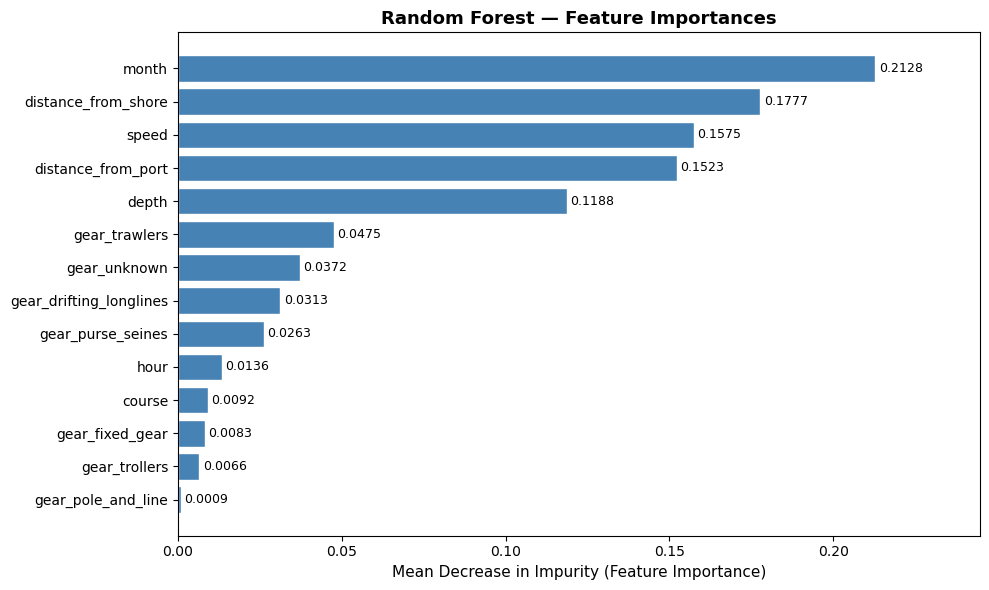

In [10]:

import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = importances[indices]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue', edgecolor='white')

# Annotate each bar with its value
for bar, val in zip(bars, sorted_importances[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)', fontsize=11)
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlim(0, sorted_importances.max() * 1.15)
plt.tight_layout()
plt.show()


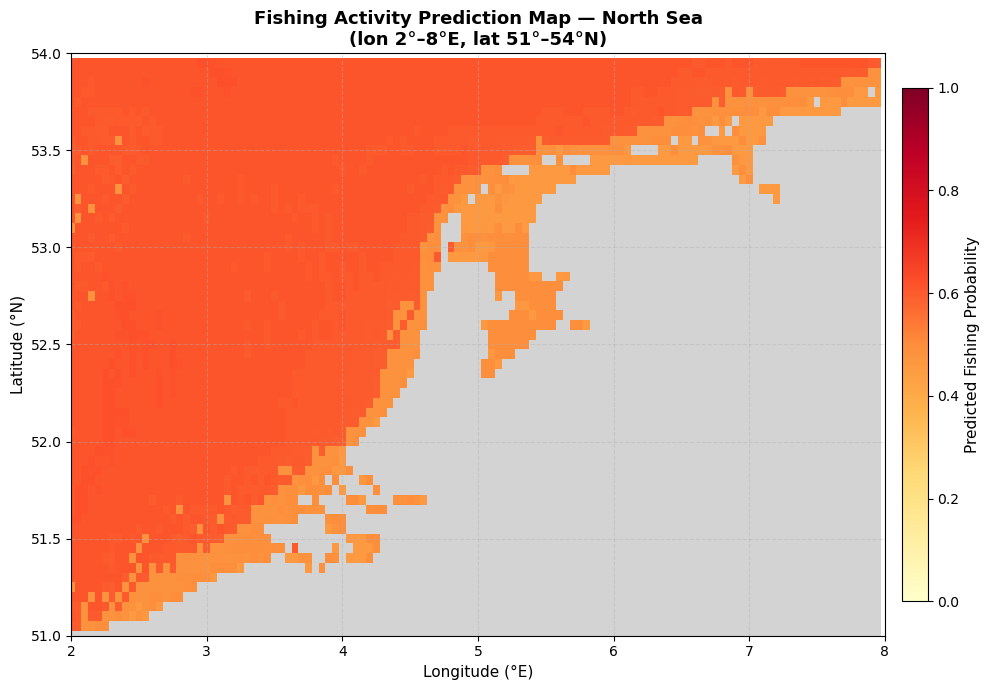

Grid shape: (60, 120)  (7200 cells @ 0.05° resolution)


In [11]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.sample import sample_gen

# --- North Sea grid ---
LON_MIN, LON_MAX = 2, 8
LAT_MIN, LAT_MAX = 51, 54
RESOLUTION = 0.05   # degrees per grid cell

lon_vals = np.arange(LON_MIN, LON_MAX, RESOLUTION)
lat_vals = np.arange(LAT_MIN, LAT_MAX, RESOLUTION)
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
coords_grid = list(zip(lon_grid.ravel(), lat_grid.ravel()))

# --- Sample depth from bathymetry raster ---
with rasterio.open(BATHY_PATH) as src:
    depth_grid = np.array([v[0] for v in sample_gen(src, coords_grid)], dtype=float)

# --- Build feature DataFrame for the grid ---
# Use training-set medians for non-spatial features
medians = X_train[['distance_from_shore', 'distance_from_port',
                    'speed', 'course', 'hour', 'month']].median()

grid_df = pd.DataFrame({
    'distance_from_shore': medians['distance_from_shore'],
    'distance_from_port' : medians['distance_from_port'],
    'speed'              : medians['speed'],
    'course'             : medians['course'],
    'depth'              : depth_grid,
    'hour'               : medians['hour'],
    'month'              : medians['month'],
})

# Add gear dummies — use training-set mean probabilities (soft representation)
for col in gear_cols:
    grid_df[col] = X_train[col].mean()

# Ensure column order matches training
grid_df = grid_df[feature_cols]

# --- Predict fishing probability ---
prob_fishing = rf.predict_proba(grid_df)[:, 1]
prob_map = prob_fishing.reshape(lat_grid.shape)

# Mask land (depth > 0 = above sea level)
prob_map_masked = np.where(depth_grid.reshape(lat_grid.shape) > 0, np.nan, prob_map)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

cmap = plt.cm.YlOrRd
cmap.set_bad(color='lightgrey')   # land in grey

im = ax.pcolormesh(lon_grid, lat_grid, prob_map_masked,
                   cmap=cmap, vmin=0, vmax=1, shading='auto')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Predicted Fishing Probability', fontsize=11)

ax.set_title('Fishing Activity Prediction Map — North Sea\n'
             f'(lon {LON_MIN}°–{LON_MAX}°E, lat {LAT_MIN}°–{LAT_MAX}°N)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude (°E)', fontsize=11)
ax.set_ylabel('Latitude (°N)', fontsize=11)
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
# Gridlines
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
print(f"Grid shape: {prob_map.shape}  ({prob_map.size} cells @ {RESOLUTION}° resolution)")


Depth-only model train accuracy: 0.5863
Total grid points: 180,000


c:\Users\balar\anaconda4\envs\ocean_ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


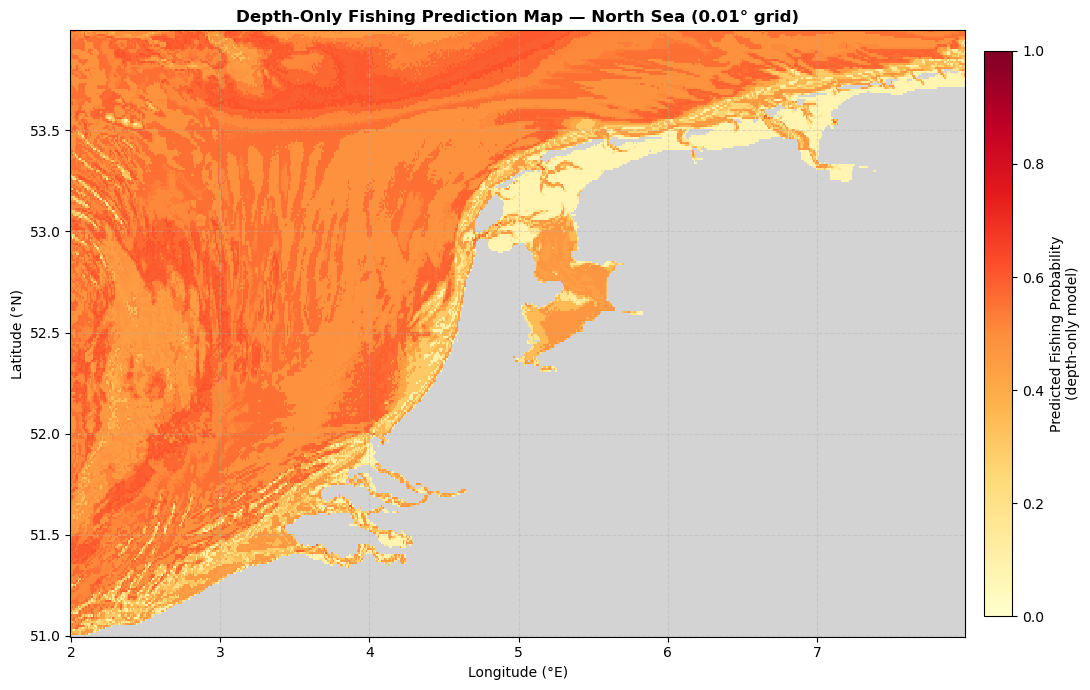

Saved 8,938 points → ../data/fish_predict/north_sea_fishing_prediction.geojson


In [12]:

import json
import numpy as np
import rasterio
from rasterio.sample import sample_gen
from sklearn.ensemble import RandomForestClassifier as RFC
import matplotlib.pyplot as plt

# ── 1. Train a depth-only model ─────────────────────────────────────────────
rf_depth = RFC(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_depth.fit(df_sub[['depth']], df_sub['is_fishing'])
print(f"Depth-only model train accuracy: {rf_depth.score(df_sub[['depth']], df_sub['is_fishing']):.4f}")

# ── 2. Build 0.01° grid for North Sea ───────────────────────────────────────
LON_MIN, LON_MAX = 2.0, 8.0
LAT_MIN, LAT_MAX = 51.0, 54.0
RES = 0.01

lons = np.arange(LON_MIN, LON_MAX, RES)
lats = np.arange(LAT_MIN, LAT_MAX, RES)
lon_g, lat_g = np.meshgrid(lons, lats)
coords_fine = list(zip(lon_g.ravel(), lat_g.ravel()))
print(f"Total grid points: {len(coords_fine):,}")

# ── 3. Extract depth for every grid point ───────────────────────────────────
with rasterio.open(BATHY_PATH) as src:
    depths_fine = np.array([v[0] for v in sample_gen(src, coords_fine)], dtype=float)

# ── 4. Predict fishing probability (ocean cells only) ───────────────────────
ocean_mask = depths_fine <= 0         # True = ocean / sea
depth_ocean = depths_fine[ocean_mask].reshape(-1, 1)
prob_ocean  = rf_depth.predict_proba(depth_ocean)[:, 1]

probs_all = np.full(len(coords_fine), np.nan)
probs_all[ocean_mask] = prob_ocean

# Reshape for plot
prob_map_fine = probs_all.reshape(lon_g.shape)

# Quick static map
fig, ax = plt.subplots(figsize=(11, 7))
cmap = plt.cm.YlOrRd
cmap.set_bad('lightgrey')
im = ax.pcolormesh(lon_g, lat_g,
                   np.ma.masked_invalid(prob_map_fine),
                   cmap=cmap, vmin=0, vmax=1, shading='auto')
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Predicted Fishing Probability\n(depth-only model)', fontsize=10)
ax.set_title('Depth-Only Fishing Prediction Map — North Sea (0.01° grid)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°N)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── 5. Subsample every 10th point and save as GeoJSON ───────────────────────
lons_flat  = lon_g.ravel()
lats_flat  = lat_g.ravel()

# Keep every 10th ocean point that has a valid probability
valid_idx = np.where(ocean_mask)[0][::10]

features = []
for i in valid_idx:
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [round(float(lons_flat[i]), 4),
                            round(float(lats_flat[i]), 4)]
        },
        "properties": {
            "depth":            round(float(depths_fine[i]), 1),
            "fishing_prob":     round(float(probs_all[i]),   4)
        }
    })

geojson = {"type": "FeatureCollection", "features": features}

OUTPUT_PATH = "../data/fish_predict/north_sea_fishing_prediction.geojson"
with open(OUTPUT_PATH, "w") as f:
    json.dump(geojson, f)

print(f"Saved {len(features):,} points → {OUTPUT_PATH}")
